# Selección de variables con pyWinEA para presión arterial media (MAP)

Este notebook usa **pyWinEA** para seleccionar variables mediante **Algoritmos Genéticos** sobre el dataset del proyecto ubicado en `data/`.

La variable objetivo se construye como **presión arterial media (MAP)**:

\[
MAP = \frac{SBP + 2 \cdot DBP}{3}
\]

donde `SBP` es la presión sistólica y `DBP` la presión diastólica.

> Nota metodológica: después de crear el target, se eliminan las columnas de presión sistólica/diastólica del conjunto de predictores para evitar *data leakage*.


In [2]:
%env SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True

env: SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True


In [3]:
%pip install pyWinEA

  Using cached pywinEA-0.0.2-py3-none-any.whl.metadata (6.4 kB)
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Created wheel for sklearn: filename=sklearn-0.0.post12-py3-none-any.whl size=2219 sha256=833a7905a732cdbc1ec97bbd4e0578e41c7545a2b0069ea00028020d194516d0
  Stored in directory: c:\users\usuario\appdata\local\pip\cache\wheels\df\a3\e3\6a1b9d42118569a572597a7422f9b58212f28fdaa9b18e8c10
Successfully built sklearn

   -------------------------- ------------- 2/3 [pyWinEA]
   ---------------------------------------- 3/3 [pyWinEA]

Note: you may

In [1]:
import pywinEA
print("pyWinEA ok")

pyWinEA ok


c:\Users\Usuario\miniconda3\envs\tfm\Lib\site-packages\pywinEA\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [2]:
# ============================================================
# 1. Imports generales
# ============================================================

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


In [3]:
# ============================================================
# 2. Carga del dataset desde la carpeta data/
# ============================================================



dataset_path = Path("data/full_dataset.csv")
print(f"Dataset encontrado: {dataset_path}")

if dataset_path.suffix.lower() == ".csv":
    df = pd.read_csv(dataset_path)
elif dataset_path.suffix.lower() == ".parquet":
    df = pd.read_parquet(dataset_path)
elif dataset_path.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(dataset_path)
else:
    raise ValueError(f"Formato no soportado: {dataset_path.suffix}")

print(df.shape)
df.head()


Dataset encontrado: data\full_dataset.csv
(2527, 108)


,genero,edad,etnia_1,etnia_3,mes_examen,pais_nacimiento,tamano_hogar,peso_entrevista,peso_examen,estrato,...,mercurio_si,com_mercurio,selenio,selenio_si,manganeso,manganeso_si,movilidad,neurologico,osteoporosis,equilibrio
0,1.0,43.0,5.0,6.0,2.0,2.0,4.0,50055.450807,54374.463898,173.0,...,5.04,5.397605e-79,189.2,2.40,10.94,199.13,0.0,1.0,1.0,1.0
1,1.0,66.0,3.0,3.0,2.0,1.0,2.0,29087.450605,34084.721548,173.0,...,48.10,5.397605e-79,192.3,2.44,7.74,140.88,0.0,1.0,1.0,1.0
2,2.0,44.0,2.0,2.0,1.0,2.0,7.0,80062.674301,81196.277992,174.0,...,2.74,5.397605e-79,160.5,2.04,11.93,217.15,1.0,1.0,1.0,1.0
3,1.0,34.0,1.0,1.0,1.0,1.0,3.0,30995.282610,39988.452940,179.0,...,1.70,5.397605e-79,183.3,2.33,10.94,199.13,0.0,1.0,1.0,1.0
4,1.0,51.0,3.0,3.0,1.0,1.0,4.0,41925.463225,51305.024430,174.0,...,1.35,5.397605e-79,185.0,2.35,9.36,170.37,0.0,1.0,1.0,1.0


In [4]:
# ============================================================
# 3. Detección automática de columnas de presión arterial
# ============================================================

def columnas_existentes(df, candidatas):
    return [c for c in candidatas if c in df.columns]

# Nombres posibles según trabajo previo del proyecto y nombres NHANES habituales.
sistolicas_candidatas = ["sistolica_1", "sistolica_2", "sistolica_3"]
diastolicas_candidatas = ["diastolica_1", "diastolica_2", "diastolica_3"]

cols_sistolica = columnas_existentes(df, sistolicas_candidatas)
cols_diastolica = columnas_existentes(df, diastolicas_candidatas)

print("Columnas sistólicas detectadas:", cols_sistolica)
print("Columnas diastólicas detectadas:", cols_diastolica)

if not cols_sistolica or not cols_diastolica:
    raise ValueError(
        "No se han detectado columnas de presión sistólica y/o diastólica. "
        "Revisa los nombres de columnas o añade sus nombres a las listas de candidatas."
    )


Columnas sistólicas detectadas: ['sistolica_1', 'sistolica_2', 'sistolica_3']
Columnas diastólicas detectadas: ['diastolica_1', 'diastolica_2', 'diastolica_3']


In [5]:
# ============================================================
# 4. Creación de target: presión arterial media
# ============================================================

df_model = df.copy()

# Convertimos las columnas detectadas a numéricas por seguridad.
for col in cols_sistolica + cols_diastolica:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model["media_sistolica"] = df_model[cols_sistolica].mean(axis=1)
df_model["media_diastolica"] = df_model[cols_diastolica].mean(axis=1)

# MAP = (SBP + 2*DBP) / 3
df_model["map_mmHg"] = (df_model["media_sistolica"] + 2 * df_model["media_diastolica"]) / 3

# Target binario útil para pyWinEA con clasificadores:
# 1 = MAP alta o compatible con mayor riesgo, 0 = MAP normal/baja.
# Umbral inicial conservador: MAP >= 90 mmHg.
df_model["target_map_alta"] = (df_model["map_mmHg"] >= 90).astype(int)

df_model[["media_sistolica", "media_diastolica", "map_mmHg", "target_map_alta"]].describe()


,media_sistolica,media_diastolica,map_mmHg,target_map_alta
count,2469.000000,2469.000000,2469.000000,2527.000000
mean,119.887674,75.396787,90.227082,0.449545
std,16.414944,10.718115,11.662332,0.497546
min,70.000000,41.000000,51.333333,0.000000
25%,109.000000,68.000000,82.333333,0.000000
50%,117.666667,74.666667,88.888889,0.000000
75%,128.333333,81.666667,96.666667,1.000000
max,202.333333,131.000000,148.222222,1.000000


In [6]:
# ============================================================
# 5. Preparación de X e y
# ============================================================

# Para selección de variables evitamos fuga de información:
# quitamos las columnas usadas para calcular el target y posibles columnas target previas.
columnas_a_excluir = set(cols_sistolica + cols_diastolica + [
    "media_sistolica",
    "media_diastolica",
    "map_mmHg",
    "target_map_alta"
])

# También quitamos identificadores obvios si existen.
ids_posibles = ["SEQN", "id", "ID", "participant_id"]
columnas_a_excluir.update([c for c in ids_posibles if c in df_model.columns])

df_model = df_model.dropna(subset=["map_mmHg", "target_map_alta"]).copy()

X_raw = df_model.drop(columns=[c for c in columnas_a_excluir if c in df_model.columns])
y_reg = df_model["map_mmHg"]
y_clf = df_model["target_map_alta"]

print("X_raw:", X_raw.shape)
print("Target regresión:", y_reg.shape)
print("Target clasificación:", y_clf.value_counts(normalize=True).rename("proporcion"))


X_raw: (2469, 102)
Target regresión: (2469,)
Target clasificación: target_map_alta
0    0.539895
1    0.460105
Name: proporcion, dtype: float64


In [7]:
# ============================================================
# 6. Preprocesamiento
# ============================================================

# Detectamos tipos de columnas.
numeric_cols = X_raw.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

print(f"Variables numéricas: {len(numeric_cols)}")
print(f"Variables categóricas: {len(categorical_cols)}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_processed = preprocessor.fit_transform(X_raw)

try:
    feature_names = preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_processed.shape[1])]

X_processed = pd.DataFrame(X_processed, columns=feature_names, index=X_raw.index)

print("Matriz procesada:", X_processed.shape)
X_processed.head()


Variables numéricas: 100
Variables categóricas: 2
Matriz procesada: (2469, 105)


,genero,edad,etnia_1,etnia_3,mes_examen,pais_nacimiento,tamano_hogar,peso_entrevista,peso_examen,estrato,...,manganeso_si,movilidad,neurologico,osteoporosis,equilibrio,brazo_b'L',brazo_b'R',sonda_b'',sonda_b'M',sonda_b'XL'
0,-1.128486,-0.401446,1.887312,1.945391,0.932222,1.861381,0.900873,0.713062,0.354326,-1.570065,...,0.383253,-0.405737,0.10515,0.040283,0.363386,0.0,1.0,0.0,1.0,0.0
1,-1.128486,1.197552,-0.075524,-0.181160,0.932222,-0.537236,-0.466637,-0.206519,-0.300789,-1.570065,...,-0.527381,-0.405737,0.10515,0.040283,0.363386,0.0,1.0,0.0,0.0,1.0
2,0.886143,-0.331924,-1.056943,-0.890011,-1.072705,1.861381,2.952137,2.029070,1.220348,-1.334139,...,0.664964,2.464650,0.10515,0.040283,0.363386,0.0,1.0,0.0,1.0,0.0
3,-1.128486,-1.027141,-2.038361,-1.598861,-1.072705,-0.537236,0.217118,-0.122848,-0.110169,-0.154512,...,0.383253,-0.405737,0.10515,0.040283,0.363386,0.0,1.0,0.0,1.0,0.0
4,-1.128486,0.154727,-0.075524,-0.181160,-1.072705,-0.537236,0.900873,0.356510,0.255220,-1.334139,...,-0.066357,-0.405737,0.10515,0.040283,0.363386,0.0,1.0,0.0,1.0,0.0


In [8]:
# ============================================================
# 7. Split train/test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print(X_train.shape, X_test.shape)


(1975, 105) (494, 105)


## 8. Selección de variables con pyWinEA

La librería implementa algoritmos genéticos compatibles con modelos de `scikit-learn`. En esta versión del notebook usamos una tarea de **clasificación** (`target_map_alta`) porque es el flujo más estable de la API pública de pyWinEA.

El target continuo `map_mmHg` queda creado igualmente, por si después se quiere plantear una versión de regresión.


In [10]:
# ============================================================
# 8. Selección de variables con pyWinEA
# ============================================================

try:
    from pywinEA.algorithm import GA
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install git+https://github.com/FernandoGaGu/pywinEA.git
    from pywinEA.algorithm import GA

# Fitness: modelo rápido y estable para selección inicial.
fitness_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

POPULATION_SIZE = 30
GENERATIONS = 40
CV = 5
ANNIHILATION = 0.10
ELITISM = 0.20
MUTATION_RATE = 0.10

ga = GA(
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    cv=CV,
    fitness=fitness_model,
    annihilation=ANNIHILATION,
    elitism=ELITISM,
    mutation_rate=MUTATION_RATE,
    positive_class=1,
    id="GA_MAP_alta"
)

ga.set_features(X_train.columns.tolist())
ga.fit(X_train.values, y_train.values)

selected_features = list(ga.best_features)

print(f"Nº variables originales procesadas: {X_train.shape[1]}")
print(f"Nº variables seleccionadas por pyWinEA: {len(selected_features)}")
selected_features[:50]


 (BasicGA) Generations (form 0 to 40): 100%|██████████| 40/40 [02:23<00:00,  3.59s/it]

Nº variables originales procesadas: 105
Nº variables seleccionadas por pyWinEA: 60


['peso_dieta',
 'ldl_martin',
 'estado_higado',
 'ldl_nih_si',
 'vpm',
 "sonda_b''",
 'mercurio_si',
 'med_validas',
 'iqr_rigidez',
 'plomo_si',
 'hcm',
 'linfocitos_abs',
 'equilibrio',
 'manganeso',
 'ratio_pobreza',
 'manguito',
 'manganeso_si',
 'ratio_iqrm',
 'neutrofilos_abs',
 'iqr_cap',
 'ldl',
 'monocitos_abs',
 '_monocitos',
 'intentos',
 'selenio_si',
 'albmina_si',
 'peso_examen',
 '_linfocitos',
 'movilidad',
 'trigliceridos',
 'peso_ayuno',
 'peso_entrevista',
 'etnia_1',
 'ldl_si',
 'genero',
 'pulso_3',
 'com_albumina',
 'edad',
 'romberg_3_seg',
 'cap_dbm',
 'estrato',
 'cadmio_si',
 'ldl_martin_si',
 'trigli_si',
 'hematocrito',
 'chcm',
 'cadmio',
 'plaquetas',
 'uso_suplementos',
 'selenio']

In [11]:
# ============================================================
# 9. Evaluación comparativa:
#    todas las variables vs variables seleccionadas por pyWinEA
# ============================================================

def evaluar_clasificador(nombre, X_train_eval, X_test_eval, y_train, y_test):
    modelo = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
    modelo.fit(X_train_eval, y_train)
    pred = modelo.predict(X_test_eval)

    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test_eval)[:, 1]
        roc = roc_auc_score(y_test, proba)
    else:
        roc = np.nan

    return {
        "modelo": nombre,
        "n_variables": X_train_eval.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc
    }

resultados = []

resultados.append(
    evaluar_clasificador(
        "Todas_las_variables",
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_clasificador(
        "pyWinEA_variables_seleccionadas",
        X_train[selected_features],
        X_test[selected_features],
        y_train,
        y_test
    )
)

df_resultados = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False)
df_resultados


,modelo,n_variables,accuracy,f1,roc_auc
0,Todas_las_variables,105,0.661943,0.607059,0.746069
1,pyWinEA_variables_seleccionadas,60,0.672065,0.625000,0.744205


In [12]:
# ============================================================
# 10. Guardado de resultados
# ============================================================

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

selected_features_path = OUTPUT_DIR / "variables_seleccionadas_pyWinEA_MAP.csv"
resultados_path = OUTPUT_DIR / "resultados_pyWinEA_MAP.csv"

pd.Series(selected_features, name="variable").to_csv(selected_features_path, index=False)
df_resultados.to_csv(resultados_path, index=False)

print(f"Variables seleccionadas guardadas en: {selected_features_path}")
print(f"Resultados guardados en: {resultados_path}")


Variables seleccionadas guardadas en: outputs\variables_seleccionadas_pyWinEA_MAP.csv
Resultados guardados en: outputs\resultados_pyWinEA_MAP.csv


In [13]:
# ============================================================
# 11. Importancia de variables seleccionadas
# ============================================================

modelo_final = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

modelo_final.fit(X_train[selected_features], y_train)

importancias = pd.DataFrame({
    "variable": selected_features,
    "importancia": modelo_final.feature_importances_
}).sort_values("importancia", ascending=False)

importancias_path = OUTPUT_DIR / "importancias_variables_pyWinEA_MAP.csv"
importancias.to_csv(importancias_path, index=False)

print(f"Importancias guardadas en: {importancias_path}")
importancias.head(30)


Importancias guardadas en: outputs\importancias_variables_pyWinEA_MAP.csv


,variable,importancia
37,edad,0.041697
53,imc,0.036220
39,cap_dbm,0.035069
59,peso_kg,0.031267
44,hematocrito,0.031177
25,albmina_si,0.029776
9,plomo_si,0.028892
35,pulso_3,0.024951
43,trigli_si,0.024667
29,trigliceridos,0.024258


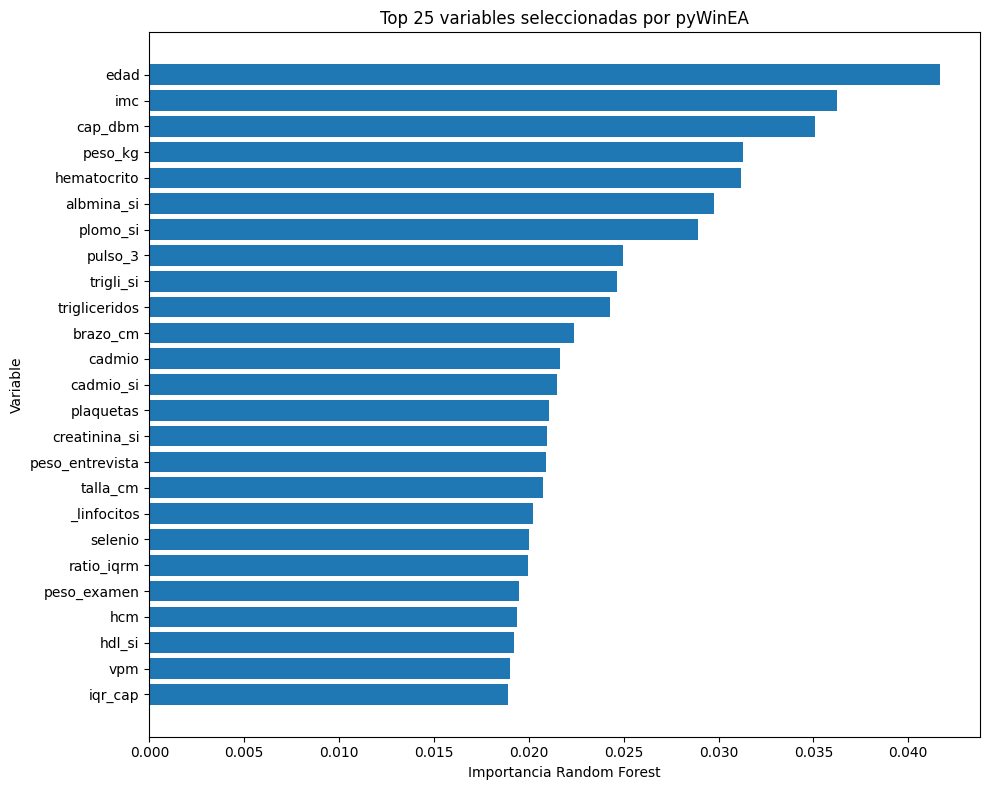

In [14]:
# ============================================================
# 12. Visualización rápida
# ============================================================

import matplotlib.pyplot as plt

top_n = 25
top_importancias = importancias.head(top_n).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_importancias["variable"], top_importancias["importancia"])
plt.title(f"Top {top_n} variables seleccionadas por pyWinEA")
plt.xlabel("Importancia Random Forest")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## Interpretación práctica

- `map_mmHg` representa la presión arterial media estimada a partir de presión sistólica y diastólica.
- `target_map_alta` transforma esa presión media en una variable binaria para selección genética con clasificadores.
- pyWinEA busca subconjuntos de variables que maximicen el rendimiento del modelo usado como `fitness`.
- La comparación final permite ver si el subconjunto seleccionado mantiene o mejora el rendimiento respecto a usar todas las variables.
- Las variables seleccionadas quedan guardadas en `outputs/variables_seleccionadas_pyWinEA_MAP.csv`.
